<a href="https://colab.research.google.com/github/terry0809000/Artificial-Intelligence-KCL/blob/main/7PAVAIHA_2026_Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 2: Constraint Optimisation and Graph Searching

<hr style="border:1px solid black"> </hr>

## IMPORTANT

Please save your own copy of this workbook and work off that. Click on `File` and select `Save a copy in Drive`

Then, click on `Runtime` above and if highlighted, click on `Restart session`

Finally, click on `edit` above and click on `Clear all outputs`

**Run time**
Note, you will only need the CPU for this practical

For the first part of the practical, we want to make sure Google Colab is using the CPU runtime (not GPU).

Step 1: Open Runtime Settings
*   Click Runtime in the top menu.
*   Click Change runtime type.

Step 2: Select CPU, then click on Save

<hr style="border:1px solid black"> </hr>

## Using AI Assistants During the Exercises

In this module, you are permitted to use ChatGPT, Gemini, or Copilot to help you understand concepts, debug code, or develop solutions.

If you choose to use an AI assistant, you must:

1.   Keep track of the prompts you use
2.   Summarise the responses you found useful
3.   Write a short reflection explaining how the AI helped your learning

Your reflection should briefly consider:

*   What you asked the AI
*   What you learned from the response
*   Whether the response was helpful, incomplete, or incorrect

### Example AI Interaction Log

Prompt:

Response summary:

What I learned from this interaction:

Was the AI response correct/helpful? Why or why not?

<hr style="border:1px solid black"> </hr>

## Exercise 1: Introduction to Constraint Satisfaction

The aim of this lab is to provide an overview of the main concepts of constraint satisfaction problems through a worked example

**Problem:** A pandemic is rising. Hospitals must organize quickly to treat ill people.
We need to design algorithm which matches infected people and hospitals together given multiple criteria such as the severity of illness, patient age and location, hospital capacity and equipment, etc.

**Exercise:** Briefly explain the following concepts:

- The difference between **constraint satisfaction problems (CSP)** and **graph search algorithms**, in simple terms.

- Why a **constraint satisfaction approach** is suitable for the hospital allocation problem described above.

- What **other AI methods** could potentially be used to solve this problem.

- The difference between **hard constraints** and **soft constraints** in CSP.

<hr style="border:1px solid black"> </hr>

**Exercise:** Modelling the Problem

Using your understanding from the previous exercise, think about how the hospital allocation problem could be modelled as a CSP.

Identify the following:

- **Variables:** What decisions must be made? (e.g., assigning patients to hospitals or beds)

- **Domains:** What possible values can each variable take?

- **Constraints:** What rules must always be satisfied? List at least three.

- **Soft constraints:** What preferences might improve the solution but are not strictly required?

Briefly describe your ideas.

<hr style="border:1px solid black"> </hr>

### OR-Tools

We will use the __[OR-Tools](https://developers.google.com/optimization)__ to solve our optimisation problem

Remember to install the OR-Tools module *before* starting the tutorial:  

In [1]:
pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.

Import all toolboxes need to support the tutorial

In [2]:
from ortools.sat.python import cp_model # CP-SAT solver

import numpy as np
from random import randint
from math import ceil
import matplotlib.pyplot as plt # Data visualization

<hr style="border:1px solid black"> </hr>

### Declare Key Parameters

Our problem space has **four key parameters** that define the model.

**Exercise:**

- Identify these parameters by examining the code below.

- Based on these values, will every patient get a bed?

In [3]:
# Number of hospitals
n_hospitals = 3
# Number of infected people
n_patients = 200
# Number of beds in every hospital
n_beds_in_hospitals = [30,50,20]
# Location of infected people -- random integer tuple (x,y)
patients_loc = [(randint(0, 100), randint(0, 100)) for _ in range(n_patients)]
# Location of hospitals -- random integer tuple (x,y)
hospitals_loc = [(randint(0, 100), randint(0, 100)) for _ in range(n_hospitals)]
# Illness severity -- 1 = mild -> 5 = severe
patients_severity = [randint(1, 5) for _ in range(n_patients)]

<hr style="border:1px solid black"> </hr>

### Visualise the problem space

**Exercise:**

- Add comments to each line of code explaining its purpose

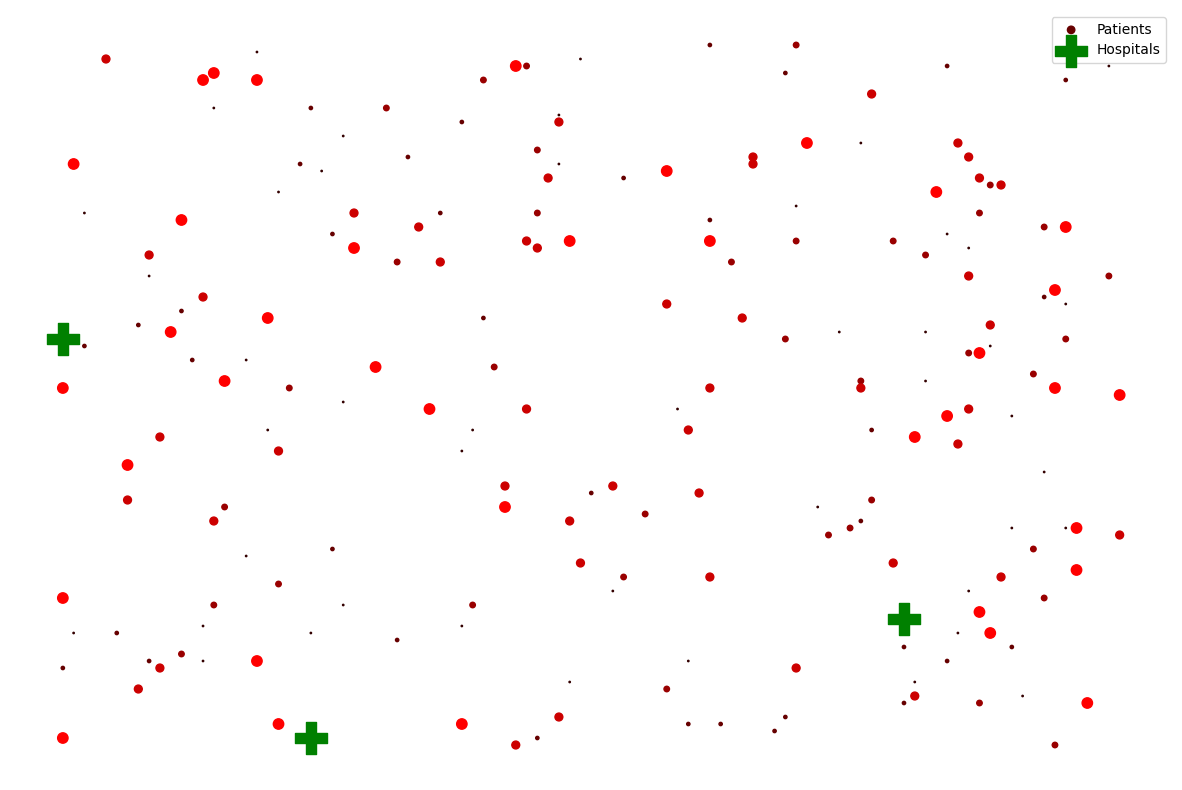

In [4]:
# Visualization
plt.rcParams["figure.figsize"] = (15,10)
# Set the size of the figure to 15 inches wide and 10 inches high for better visibility.

shade_severity = [int(sev*255/5) for sev in patients_severity]
# Convert patient severity scores into a value between 0 and 255.
# This will later be used to control the intensity of the red color (higher severity → darker red).

color_severity = ["#%02x0000" % (sev) for sev in shade_severity]
# Create color codes in hexadecimal format.
# The red component is determined by the severity level, while green and blue are 0.
# This means higher severity patients appear as darker red points.

size_severity = [k**2.5 for k in patients_severity]
# Determine the size of each point in the plot.
# Higher severity values produce larger marker sizes to make severe patients more visible.

plt.scatter(*zip(*patients_loc), s=size_severity, c=color_severity, label="Patients")
# Plot patient locations as scatter points.
# zip(*patients_loc) separates x and y coordinates.
# Marker size reflects severity, and color indicates severity intensity.

plt.scatter(*zip(*hospitals_loc), s=500, c="g", marker="P", label="Hospitals")
# Plot hospital locations.
# Points are large (size 500), colored green, and use the "P" marker shape to distinguish hospitals.

plt.legend()
# Display a legend to identify patients and hospitals in the plot.

plt.axis('off')
# Remove axis lines and tick labels to make the visualization cleaner.

plt.show()
# Render and display the final plot.

<hr style="border:1px solid black"> </hr>

### Declare Constraint Variables

A constraint satisfaction problem consists of a set of variables that must be assigned values such that a set of constraints is satisfied.

- `i` represents a hospital
- `j` represents a bed in hospital `i`
- `k` represents a patient

**Exercise:**
- Explain how the code below represents patient–bed assignments.
- What would it mean if `x[2,5,7] = 1` in this model?

In [5]:
model = cp_model.CpModel()
x = {}
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    for k in range(n_patients):
      x[(i,j,k)] = model.NewBoolVar("x(%d,%d,%d)" % (i,j,k))

#patient 7 is assigned to bed 5 in hospital 2
#The code defines binary decision variables to represent whether a patient is assigned to a specific hospital bed.
#i hospital index, jth bed inside the hospital, k patient number

<hr style="border:1px solid black"> </hr>

### Goal of our problem:
    
In order to associate each bed of an hospital to an ill person, we must find a set of variables (*n* unique combinations of `x[i,j,k] = 1`) that satisfies all of our constraints.

**Question:** what is the maximum value of *n*? Why?

n=min(number of patients,total number of beds)  because each patient can occupy at most one bed, and each bed can hold at most one patient.

<hr style="border:1px solid black"> </hr>

### Hard Constraints

Hard constraints define the rules that must be satisfied for a solution to be valid. If they are not satisfied, the problem cannot be solved.

**Exercise:** Based on the code below, identify the hard constraints and briefly describe the difference between them.

In [6]:
# Constraint #1
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    model.Add(sum(x[(i,j,k)] for k in range(n_patients)) <= 1)
#one patient per bed
#For every hospital i and bed j, the sum of all patients assigned to that bed must be at most 1.
#A single bed cannot be assigned to multiple patients.At most one patient can occupy a bed.

# Constraint #2 One bed per patient
for k in range(n_patients):
  inner_sum = []
  for i in range(n_hospitals):
    inner_sum.append(sum(x[(i,j,k)] for j in range(n_beds_in_hospitals[i])))
  model.Add(sum(inner_sum) <= 1)

#For every patient k, the sum of all beds across all hospitals assigned to that patient must be at most 1.
#A patient can be assigned to only one bed. The patient cannot occupy multiple beds or hospitals.

<hr style="border:1px solid black"> </hr>

### Soft Constraints

Soft constraints represent preferences in the model. The solution should try to satisfy them as much as possible, but they are not strictly required for a valid solution.

**Exercise:** Based on the code below, identify the soft constraints and briefly describe the differences between them.

In [7]:
# Integer distance function
idist = lambda xy1, xy2: int(((xy1[0]-xy2[0])**2 + (xy1[1]-xy2[1])**2)**0.5)

# Gain factors (1/penalty factors)
gain_max_patients = 140  #soft constraint #1 This adds a large positive reward whenever a patient is assigned to a bed.
gain_severity = int(140/5) #soft constraint #3 Prioritize patients with higher severity. Patient severity increases the score.
gain_distance = -1  #soft constraint #2 2. Minimize distance between patient and hospital, because the disctance is negative, larger distance reduces the score

# Maximization objective
soft_csts = []
for i in range(n_hospitals):
  for j in range(n_beds_in_hospitals[i]):
    for k in range(n_patients):
      factor = \
        gain_max_patients \
        + gain_distance * idist(hospitals_loc[i], patients_loc[k]) \
        + gain_severity * patients_severity[k]
      soft_csts.append(factor * x[(i,j,k)])

model.Maximize(sum(soft_csts))

**Exercise:** What is the difference between how hard constraints and soft constraints are expressed in the model?
Hard constraints ensure the solution is feasible, while soft constraints guide the solver to find the best possible assignment among all feasible solutions.

<hr style="border:1px solid black"> </hr>

### Run Solver
Now we can launch the solver. As the optimal solution may take time to find, this code is set up to find the optimal solution within a specified time limit. If it can’t manage to find the optimal solution, it will return the closest sub-optimal solution.

In [8]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 60
status = solver.Solve(model)

### Print out patient assignments

**Exercise:**

- Add comments to each line of code explaining its purpose

In [9]:
# Create a list to store the lines that will later be plotted between hospitals and assigned patients
plot_lines = [[] for _ in range(n_hospitals)]

# Loop through each hospital
for i in range(n_hospitals):

    # Print the hospital index
    print("Hospital ", i)

    # Loop through each bed in hospital i
    for j in range(n_beds_in_hospitals[i]):

        # Loop through each patient
        for k in range(n_patients):

            # Check if patient k is assigned to bed j in hospital i (value = 1 means assigned)
            if solver.Value(x[(i, j, k)]) == 1:

                # Print which patient is assigned to which bed
                print("\tPatient ", k, "in bed ", j)

                # Get x-coordinates (horizontal axis) of the hospital and the patient
                line_abs = [hospitals_loc[i][0], patients_loc[k][0]]

                # Get y-coordinates (vertical axis) of the hospital and the patient
                line_ord = [hospitals_loc[i][1], patients_loc[k][1]]

                # Store the coordinates of the line connecting hospital and patient
                plot_lines[i].append([line_abs, line_ord])

# Print an empty line for readability
print()

# Print the total time the solver took to compute the solution
print("Inference time: %f s" % solver.WallTime())

Hospital  0
	Patient  65 in bed  0
	Patient  117 in bed  1
	Patient  133 in bed  2
	Patient  142 in bed  3
	Patient  44 in bed  4
	Patient  94 in bed  5
	Patient  6 in bed  6
	Patient  143 in bed  7
	Patient  27 in bed  8
	Patient  138 in bed  9
	Patient  72 in bed  10
	Patient  96 in bed  11
	Patient  193 in bed  12
	Patient  148 in bed  13
	Patient  11 in bed  14
	Patient  176 in bed  15
	Patient  121 in bed  16
	Patient  192 in bed  17
	Patient  141 in bed  18
	Patient  49 in bed  19
	Patient  21 in bed  20
	Patient  5 in bed  21
	Patient  63 in bed  22
	Patient  7 in bed  23
	Patient  71 in bed  24
	Patient  42 in bed  25
	Patient  81 in bed  26
	Patient  25 in bed  27
	Patient  107 in bed  28
	Patient  190 in bed  29
Hospital  1
	Patient  8 in bed  0
	Patient  53 in bed  1
	Patient  100 in bed  2
	Patient  108 in bed  3
	Patient  43 in bed  4
	Patient  198 in bed  5
	Patient  119 in bed  6
	Patient  115 in bed  7
	Patient  150 in bed  8
	Patient  179 in bed  9
	Patient  32 in bed 

### Visualise Results

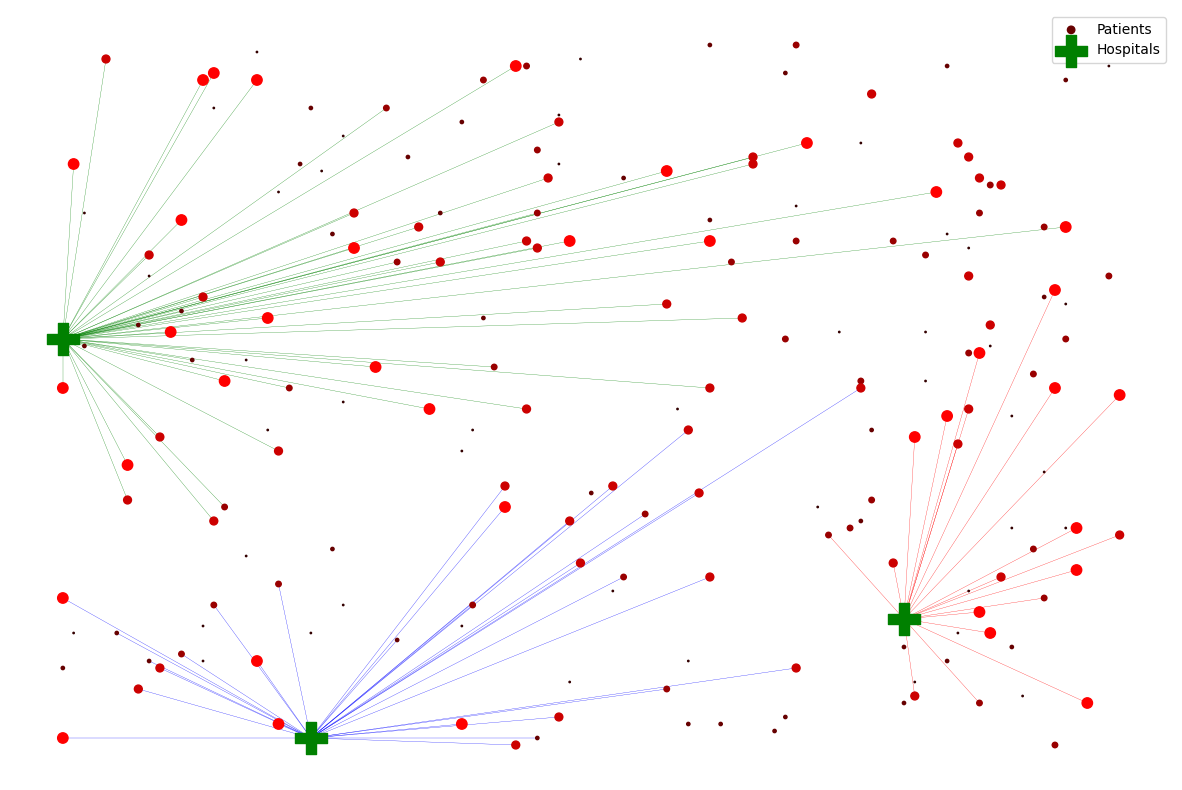

In [10]:
from itertools import cycle

shade_severity = [int(sev*255/5) for sev in patients_severity]
color_severity = ["#%02x0000" % (sev) for sev in shade_severity]
size_severity = [k**2.5 for k in patients_severity]
plt.scatter(*zip(*patients_loc), s=size_severity, c=color_severity, label="Patients", zorder=2)
plt.scatter(*zip(*hospitals_loc), s=500, c="g", marker="P", label="Hospitals", zorder=3)
colors = cycle('bgrcmk')
for i in range(n_hospitals):
  c = next(colors)
  for (x_,y_) in plot_lines[i]:
    plt.plot(x_,y_,c=c,linewidth=0.2, zorder=1)
plt.legend()
plt.axis('off')
plt.show()

<hr style="border:1px solid black"> </hr>

## Simulation Experiments

### Simulation Experiments

Constraint satisfaction models allow us to quickly explore different scenarios by changing parameters and solving the problem again.

**Exercise:** Experiment with the model by changing the core parameters and running at least **six different simulations**.

For each simulation, record:
- the parameter values you changed
- whether all patients were assigned a bed
- how the assignments differ from the previous runs

Example scenarios to explore:

- Increase the number of patients
- Change the number of hospitals or vary hospital capacity
- Modify the hard or soft constraints
- Combine several changes at once

Briefly compare the outputs and describe how these changes affect the solution.

Try to find combinations of parameters that make the problem **more difficult or impossible to solve**.

Describe what changes you made and explain why they make the constraints harder to satisfy.

In [11]:
from ortools.sat.python import cp_model
import math

def run_simulation(sim_name, hospitals_loc, n_beds_in_hospitals, patients_loc, patients_severity,
                   gain_max_patients=140, gain_severity=int(140/5), gain_distance=-1,
                   max_distance=None):
    """
    Solve one hospital-bed-patient assignment simulation and print results.
    """

    # Number of hospitals and patients
    n_hospitals = len(hospitals_loc)
    n_patients = len(patients_loc)

    # Integer Euclidean distance
    def idist(xy1, xy2):
        return int(((xy1[0] - xy2[0])**2 + (xy1[1] - xy2[1])**2) ** 0.5)

    # Create model
    model = cp_model.CpModel()

    # Decision variables: x[(i,j,k)] = 1 if patient k assigned to bed j in hospital i
    x = {}
    for i in range(n_hospitals):
        for j in range(n_beds_in_hospitals[i]):
            for k in range(n_patients):
                x[(i, j, k)] = model.NewBoolVar(f"x[{i},{j},{k}]")

    # ------------------------
    # Hard constraint 1:
    # Each bed can have at most one patient
    # ------------------------
    for i in range(n_hospitals):
        for j in range(n_beds_in_hospitals[i]):
            model.Add(sum(x[(i, j, k)] for k in range(n_patients)) <= 1)

    # ------------------------
    # Hard constraint 2:
    # Each patient can have at most one bed
    # ------------------------
    for k in range(n_patients):
        model.Add(
            sum(
                x[(i, j, k)]
                for i in range(n_hospitals)
                for j in range(n_beds_in_hospitals[i])
            ) <= 1
        )

    # ------------------------
    # Optional hard constraint:
    # Only allow assignments within a maximum distance
    # ------------------------
    if max_distance is not None:
        for i in range(n_hospitals):
            for j in range(n_beds_in_hospitals[i]):
                for k in range(n_patients):
                    if idist(hospitals_loc[i], patients_loc[k]) > max_distance:
                        model.Add(x[(i, j, k)] == 0)

    # ------------------------
    # Soft constraints / objective
    # ------------------------
    soft_terms = []
    for i in range(n_hospitals):
        for j in range(n_beds_in_hospitals[i]):
            for k in range(n_patients):
                factor = (
                    gain_max_patients
                    + gain_distance * idist(hospitals_loc[i], patients_loc[k])
                    + gain_severity * patients_severity[k]
                )
                soft_terms.append(factor * x[(i, j, k)])

    model.Maximize(sum(soft_terms))

    # Solve model
    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    print("=" * 70)
    print(f"Simulation: {sim_name}")
    print(f"Status: {solver.StatusName(status)}")

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        assigned = []
        assigned_patients = set()

        for i in range(n_hospitals):
            print(f"Hospital {i}")
            for j in range(n_beds_in_hospitals[i]):
                for k in range(n_patients):
                    if solver.Value(x[(i, j, k)]) == 1:
                        dist = idist(hospitals_loc[i], patients_loc[k])
                        sev = patients_severity[k]
                        assigned.append((i, j, k, dist, sev))
                        assigned_patients.add(k)
                        print(f"  Bed {j}: Patient {k} | Severity={sev} | Distance={dist}")

        print()
        print(f"Assigned patients: {len(assigned_patients)} / {n_patients}")
        print("All patients assigned:", len(assigned_patients) == n_patients)
        print(f"Objective value: {solver.ObjectiveValue():.2f}")
        print(f"Inference time: {solver.WallTime():.4f} s")

        return {
            "simulation": sim_name,
            "status": solver.StatusName(status),
            "assigned_count": len(assigned_patients),
            "all_assigned": len(assigned_patients) == n_patients,
            "assignments": assigned
        }

    else:
        print("No feasible solution found.")
        return {
            "simulation": sim_name,
            "status": solver.StatusName(status),
            "assigned_count": 0,
            "all_assigned": False,
            "assignments": []
        }

In [12]:
# -------------------------
# Simulation 1: Baseline
# -------------------------
result_1 = run_simulation(
    sim_name="Baseline",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=n_beds_in_hospitals,
    patients_loc=patients_loc,
    patients_severity=patients_severity
)

Simulation: Baseline
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 65 | Severity=4 | Distance=56
  Bed 1: Patient 117 | Severity=3 | Distance=22
  Bed 2: Patient 133 | Severity=3 | Distance=16
  Bed 3: Patient 142 | Severity=4 | Distance=50
  Bed 4: Patient 44 | Severity=3 | Distance=24
  Bed 5: Patient 94 | Severity=4 | Distance=40
  Bed 6: Patient 6 | Severity=4 | Distance=39
  Bed 7: Patient 143 | Severity=4 | Distance=43
  Bed 8: Patient 27 | Severity=4 | Distance=46
  Bed 9: Patient 138 | Severity=4 | Distance=19
  Bed 10: Patient 72 | Severity=2 | Distance=16
  Bed 11: Patient 96 | Severity=5 | Distance=37
  Bed 12: Patient 193 | Severity=5 | Distance=30
  Bed 13: Patient 148 | Severity=3 | Distance=44
  Bed 14: Patient 11 | Severity=4 | Distance=17
  Bed 15: Patient 176 | Severity=4 | Distance=23
  Bed 16: Patient 121 | Severity=4 | Distance=71
  Bed 17: Patient 192 | Severity=2 | Distance=21
  Bed 18: Patient 141 | Severity=5 | Distance=12
  Bed 19: Patient 49 | Severity=2 | Dist

In [13]:
# -------------------------
# Simulation 2: More patients
# -------------------------
patients_loc_2 = patients_loc + [(10, 10), (12, 15), (18, 8), (22, 17), (6, 19)]
patients_severity_2 = patients_severity + [5, 4, 3, 2, 5]

result_2 = run_simulation(
    sim_name="More patients",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=n_beds_in_hospitals,
    patients_loc=patients_loc_2,
    patients_severity=patients_severity_2
)

Simulation: More patients
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 142 | Severity=4 | Distance=50
  Bed 1: Patient 117 | Severity=3 | Distance=22
  Bed 2: Patient 96 | Severity=5 | Distance=37
  Bed 3: Patient 72 | Severity=2 | Distance=16
  Bed 4: Patient 143 | Severity=4 | Distance=43
  Bed 5: Patient 138 | Severity=4 | Distance=19
  Bed 6: Patient 44 | Severity=3 | Distance=24
  Bed 7: Patient 94 | Severity=4 | Distance=40
  Bed 8: Patient 11 | Severity=4 | Distance=17
  Bed 9: Patient 21 | Severity=4 | Distance=45
  Bed 10: Patient 7 | Severity=3 | Distance=37
  Bed 11: Patient 176 | Severity=4 | Distance=23
  Bed 12: Patient 202 | Severity=3 | Distance=9
  Bed 13: Patient 6 | Severity=4 | Distance=39
  Bed 14: Patient 193 | Severity=5 | Distance=30
  Bed 15: Patient 148 | Severity=3 | Distance=44
  Bed 16: Patient 200 | Severity=5 | Distance=16
  Bed 17: Patient 133 | Severity=3 | Distance=16
  Bed 18: Patient 141 | Severity=5 | Distance=12
  Bed 19: Patient 5 | Severity=3 | Di

In [14]:
# -------------------------
# Simulation 3: Reduced hospital capacity
# -------------------------
reduced_beds = [max(1, b - 2) for b in n_beds_in_hospitals]

result_3 = run_simulation(
    sim_name="Reduced hospital capacity",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=reduced_beds,
    patients_loc=patients_loc,
    patients_severity=patients_severity
)

Simulation: Reduced hospital capacity
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 21 | Severity=4 | Distance=45
  Bed 1: Patient 121 | Severity=4 | Distance=71
  Bed 2: Patient 148 | Severity=3 | Distance=44
  Bed 3: Patient 11 | Severity=4 | Distance=17
  Bed 4: Patient 176 | Severity=4 | Distance=23
  Bed 5: Patient 133 | Severity=3 | Distance=16
  Bed 6: Patient 27 | Severity=4 | Distance=46
  Bed 7: Patient 44 | Severity=3 | Distance=24
  Bed 8: Patient 7 | Severity=3 | Distance=37
  Bed 9: Patient 117 | Severity=3 | Distance=22
  Bed 10: Patient 143 | Severity=4 | Distance=43
  Bed 11: Patient 142 | Severity=4 | Distance=50
  Bed 12: Patient 5 | Severity=3 | Distance=21
  Bed 13: Patient 193 | Severity=5 | Distance=30
  Bed 14: Patient 96 | Severity=5 | Distance=37
  Bed 15: Patient 138 | Severity=4 | Distance=19
  Bed 16: Patient 141 | Severity=5 | Distance=12
  Bed 17: Patient 6 | Severity=4 | Distance=39
  Bed 18: Patient 94 | Severity=4 | Distance=40
  Bed 19: Patient 71 | Sev

In [15]:
# -------------------------
# Simulation 4: Add a new hospital
# -------------------------
hospitals_loc_4 = hospitals_loc + [(15, 15)]
beds_4 = n_beds_in_hospitals + [4]

result_4 = run_simulation(
    sim_name="Added one hospital",
    hospitals_loc=hospitals_loc_4,
    n_beds_in_hospitals=beds_4,
    patients_loc=patients_loc,
    patients_severity=patients_severity
)

Simulation: Added one hospital
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 63 | Severity=5 | Distance=23
  Bed 1: Patient 143 | Severity=4 | Distance=43
  Bed 2: Patient 21 | Severity=4 | Distance=45
  Bed 3: Patient 117 | Severity=3 | Distance=22
  Bed 4: Patient 96 | Severity=5 | Distance=37
  Bed 5: Patient 71 | Severity=4 | Distance=35
  Bed 6: Patient 81 | Severity=2 | Distance=18
  Bed 7: Patient 148 | Severity=3 | Distance=44
  Bed 8: Patient 6 | Severity=4 | Distance=39
  Bed 9: Patient 190 | Severity=4 | Distance=17
  Bed 10: Patient 192 | Severity=2 | Distance=21
  Bed 11: Patient 7 | Severity=3 | Distance=37
  Bed 12: Patient 138 | Severity=4 | Distance=19
  Bed 13: Patient 121 | Severity=4 | Distance=71
  Bed 14: Patient 142 | Severity=4 | Distance=50
  Bed 15: Patient 84 | Severity=2 | Distance=25
  Bed 16: Patient 23 | Severity=4 | Distance=62
  Bed 17: Patient 94 | Severity=4 | Distance=40
  Bed 18: Patient 11 | Severity=4 | Distance=17
  Bed 19: Patient 133 | Severity=3

In [16]:
# -------------------------
# Simulation 4: Add a new hospital
# -------------------------
hospitals_loc_4 = hospitals_loc + [(15, 15)]
beds_4 = n_beds_in_hospitals + [4]

result_4 = run_simulation(
    sim_name="Added one hospital",
    hospitals_loc=hospitals_loc_4,
    n_beds_in_hospitals=beds_4,
    patients_loc=patients_loc,
    patients_severity=patients_severity
)

Simulation: Added one hospital
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 63 | Severity=5 | Distance=23
  Bed 1: Patient 143 | Severity=4 | Distance=43
  Bed 2: Patient 21 | Severity=4 | Distance=45
  Bed 3: Patient 117 | Severity=3 | Distance=22
  Bed 4: Patient 96 | Severity=5 | Distance=37
  Bed 5: Patient 71 | Severity=4 | Distance=35
  Bed 6: Patient 81 | Severity=2 | Distance=18
  Bed 7: Patient 148 | Severity=3 | Distance=44
  Bed 8: Patient 6 | Severity=4 | Distance=39
  Bed 9: Patient 190 | Severity=4 | Distance=17
  Bed 10: Patient 192 | Severity=2 | Distance=21
  Bed 11: Patient 7 | Severity=3 | Distance=37
  Bed 12: Patient 138 | Severity=4 | Distance=19
  Bed 13: Patient 121 | Severity=4 | Distance=71
  Bed 14: Patient 142 | Severity=4 | Distance=50
  Bed 15: Patient 84 | Severity=2 | Distance=25
  Bed 16: Patient 23 | Severity=4 | Distance=62
  Bed 17: Patient 94 | Severity=4 | Distance=40
  Bed 18: Patient 11 | Severity=4 | Distance=17
  Bed 19: Patient 133 | Severity=3

In [17]:
# -------------------------
# Simulation 5: Stronger distance penalty
# -------------------------
result_5 = run_simulation(
    sim_name="Stronger distance penalty",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=n_beds_in_hospitals,
    patients_loc=patients_loc,
    patients_severity=patients_severity,
    gain_max_patients=140,
    gain_severity=int(140/5),
    gain_distance=-5   # stronger penalty for long travel
)

Simulation: Stronger distance penalty
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 5 | Severity=3 | Distance=21
  Bed 1: Patient 84 | Severity=2 | Distance=25
  Bed 2: Patient 7 | Severity=3 | Distance=37
  Bed 3: Patient 44 | Severity=3 | Distance=24
  Bed 4: Patient 107 | Severity=3 | Distance=33
  Bed 5: Patient 163 | Severity=1 | Distance=18
  Bed 6: Patient 54 | Severity=1 | Distance=19
  Bed 7: Patient 96 | Severity=5 | Distance=37
  Bed 8: Patient 117 | Severity=3 | Distance=22
  Bed 9: Patient 157 | Severity=1 | Distance=21
  Bed 10: Patient 138 | Severity=4 | Distance=19
  Bed 11: Patient 141 | Severity=5 | Distance=12
  Bed 12: Patient 176 | Severity=4 | Distance=23
  Bed 13: Patient 133 | Severity=3 | Distance=16
  Bed 14: Patient 11 | Severity=4 | Distance=17
  Bed 15: Patient 81 | Severity=2 | Distance=18
  Bed 16: Patient 192 | Severity=2 | Distance=21
  Bed 17: Patient 177 | Severity=2 | Distance=27
  Bed 18: Patient 71 | Severity=4 | Distance=35
  Bed 19: Patient 144 | S

In [18]:
# -------------------------
# Simulation 6: Stronger severity priority
# -------------------------
result_6 = run_simulation(
    sim_name="Stronger severity priority",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=n_beds_in_hospitals,
    patients_loc=patients_loc,
    patients_severity=patients_severity,
    gain_max_patients=140,
    gain_severity=100,   # much larger reward for severe patients
    gain_distance=-1
)

Simulation: Stronger severity priority
Status: OPTIMAL
Hospital 0
  Bed 0: Patient 193 | Severity=5 | Distance=30
  Bed 1: Patient 107 | Severity=3 | Distance=33
  Bed 2: Patient 143 | Severity=4 | Distance=43
  Bed 3: Patient 117 | Severity=3 | Distance=22
  Bed 4: Patient 141 | Severity=5 | Distance=12
  Bed 5: Patient 121 | Severity=4 | Distance=71
  Bed 6: Patient 108 | Severity=4 | Distance=32
  Bed 7: Patient 71 | Severity=4 | Distance=35
  Bed 8: Patient 21 | Severity=4 | Distance=45
  Bed 9: Patient 133 | Severity=3 | Distance=16
  Bed 10: Patient 96 | Severity=5 | Distance=37
  Bed 11: Patient 11 | Severity=4 | Distance=17
  Bed 12: Patient 65 | Severity=4 | Distance=56
  Bed 13: Patient 23 | Severity=4 | Distance=62
  Bed 14: Patient 44 | Severity=3 | Distance=24
  Bed 15: Patient 63 | Severity=5 | Distance=23
  Bed 16: Patient 42 | Severity=5 | Distance=3
  Bed 17: Patient 138 | Severity=4 | Distance=19
  Bed 18: Patient 27 | Severity=4 | Distance=46
  Bed 19: Patient 29 | S

In [19]:
# -------------------------
# Bonus harder simulation:
# More patients + fewer beds + max distance
# -------------------------
patients_loc_7 = patients_loc + [(2, 25), (25, 3), (30, 30), (1, 18), (16, 27), (28, 10)]
patients_severity_7 = patients_severity + [5, 4, 5, 3, 2, 4]

beds_7 = [max(1, b - 2) for b in n_beds_in_hospitals]

result_7 = run_simulation(
    sim_name="Combined harder scenario",
    hospitals_loc=hospitals_loc,
    n_beds_in_hospitals=beds_7,
    patients_loc=patients_loc_7,
    patients_severity=patients_severity_7,
    gain_max_patients=140,
    gain_severity=80,
    gain_distance=-3,
    max_distance=10
)

Simulation: Combined harder scenario
Status: OPTIMAL
Hospital 0
  Bed 25: Patient 205 | Severity=4 | Distance=9
  Bed 26: Patient 201 | Severity=4 | Distance=2
  Bed 27: Patient 42 | Severity=5 | Distance=3
Hospital 1
  Bed 44: Patient 172 | Severity=5 | Distance=10
  Bed 45: Patient 106 | Severity=2 | Distance=7
  Bed 46: Patient 95 | Severity=2 | Distance=2
  Bed 47: Patient 90 | Severity=5 | Distance=7
Hospital 2
  Bed 8: Patient 89 | Severity=5 | Distance=7
  Bed 9: Patient 189 | Severity=1 | Distance=9
  Bed 10: Patient 154 | Severity=1 | Distance=7
  Bed 11: Patient 146 | Severity=4 | Distance=8
  Bed 12: Patient 111 | Severity=2 | Distance=4
  Bed 13: Patient 82 | Severity=2 | Distance=10
  Bed 14: Patient 73 | Severity=5 | Distance=8
  Bed 15: Patient 68 | Severity=1 | Distance=5
  Bed 16: Patient 35 | Severity=4 | Distance=10
  Bed 17: Patient 10 | Severity=2 | Distance=7

Assigned patients: 17 / 206
All patients assigned: False
Objective value: 6355.00
Inference time: 0.1696 

In [20]:
results = [result_1, result_2, result_3, result_4, result_5, result_6]

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

for r in results:
    print(
        f"{r['simulation']}: "
        f"Status={r['status']}, "
        f"Assigned={r['assigned_count']}, "
        f"All assigned={r['all_assigned']}"
    )


SUMMARY
Baseline: Status=OPTIMAL, Assigned=100, All assigned=False
More patients: Status=OPTIMAL, Assigned=100, All assigned=False
Reduced hospital capacity: Status=OPTIMAL, Assigned=94, All assigned=False
Added one hospital: Status=OPTIMAL, Assigned=104, All assigned=False
Stronger distance penalty: Status=OPTIMAL, Assigned=100, All assigned=False
Stronger severity priority: Status=OPTIMAL, Assigned=100, All assigned=False


<hr style="border:1px solid black"> </hr>

## Excercise 2: Implement your own Breadth and Depth Search

In this exercise you will implement a *Depth-First Search* (DFS) and *Breadth-First Search* (BFS) algorithm on a graph representation known as an __[adjacency list](https://www.khanacademy.org/computing/computer-science/algorithms/graph-representation/a/representing-graphs)__, which is stored as a __[dictionary](https://www.tutorialspoint.com/python3/python_dictionary.htm)__ data type in Python.

**Reflection:**

Before you begin coding, reflect on the lecture material on **Breadth-First Search (BFS)** and **Depth-First Search (DFS)**.

**Question:** How does the way nodes are stored and retrieved during the search influence the order in which nodes are explored?

**Exercise**

Implement your own versions of **BFS** and **DFS** for the graph defined below.

Your functions should:

- take a **graph (adjacency list)** and a **starting node** as input
- visit all reachable nodes in the graph
- return the **order in which nodes are visited**
- include comments explaining the core functionality

Test your implementations starting from node **S**, and compare the order in which nodes are visited by BFS and DFS.



In [21]:
# adjacency list
adj_1 = {
    'S': ['A', 'B', 'C'],
    'A': ['S', 'D', 'E'],
    'B': ['S', 'F'],
    'C': ['S', 'G'],
    'D': ['A', 'H'],
    'E': ['A', 'I'],
    'F': ['B', 'J'],
    'G': ['C'],
    'H': ['D', 'K'],
    'I': ['E'],
    'J': ['F'],
    'K': ['H']
}

In [23]:
from collections import deque

def bfs(adj_1, start):
    """
    Perform Breadth-First Search on a graph.

    Parameters:
        graph (dict): adjacency list representation of the graph
        start (str): starting node

    Returns:
        list: order of visited nodes
    """

    visited = set()              # Keeps track of visited nodes
    queue = deque([start])       # Queue stores nodes to explore (FIFO)
    order = []                   # Stores visiting order

    visited.add(start)           # Mark start node as visited

    while queue:                 # Continue until queue is empty
        node = queue.popleft()   # Remove the first node in queue
        order.append(node)       # Record the visit

        # Explore all neighbours of the current node
        for neighbor in adj_1[node]:
            if neighbor not in visited:
                visited.add(neighbor)   # Mark neighbor as visited
                queue.append(neighbor)  # Add neighbor to queue

    return order

In [24]:
def dfs(adj_1, start):
    """
    Perform Depth-First Search on a graph.

    Parameters:
        graph (dict): adjacency list representation of the graph
        start (str): starting node

    Returns:
        list: order of visited nodes
    """

    visited = set()        # Track visited nodes
    stack = [start]        # Stack stores nodes to explore (LIFO)
    order = []             # Stores visiting order

    while stack:
        node = stack.pop()   # Remove the last node added (LIFO)

        if node not in visited:
            visited.add(node)
            order.append(node)

            # Add neighbours to stack
            # Reverse keeps order consistent with adjacency list
            for neighbor in reversed(adj_1[node]):
                if neighbor not in visited:
                    stack.append(neighbor)

    return order

In [25]:
bfs_order = bfs(adj_1, "S")
dfs_order = dfs(adj_1, "S")

print("BFS visit order:", bfs_order)
print("DFS visit order:", dfs_order)

BFS visit order: ['S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
DFS visit order: ['S', 'A', 'D', 'H', 'K', 'E', 'I', 'B', 'F', 'J', 'C', 'G']


<hr style="border:1px solid black"> </hr>